In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jayjoshi37/customer-subscription-churn-and-usage-patterns")

print("Path to dataset files:", path)

Path to dataset files: /Users/ducnguyen/.cache/kagglehub/datasets/jayjoshi37/customer-subscription-churn-and-usage-patterns/versions/1


In [2]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "customer_subscription_churn_usage_patterns.csv"))

print(df.shape)
df.head()

(2800, 10)


,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   str    
 2   plan_type               2800 non-null   str    
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   str    
dtypes: float64(1), int64(6), str(3)
memory usage: 218.9 KB


In [4]:
df.describe()

,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


In [5]:
df['churn'].value_counts(normalize=True)

churn
Yes    0.573214
No     0.426786
Name: proportion, dtype: float64

In [6]:
df.duplicated().sum()

np.int64(0)

No null values, no duplicated rows

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
plan_dummies = pd.get_dummies(df['plan_type'], prefix='plan', dtype=int)
print(plan_dummies.head())

   plan_Basic  plan_Premium  plan_Standard
0           0             1              0
1           0             1              0
2           0             1              0
3           1             0              0
4           1             0              0


In [9]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [10]:
df = pd.concat([df, plan_dummies], axis=1)
df["churn_binary"] = df["churn"].map({
    "No": 0,
    "Yes": 1
})

In [11]:
corr_to_churn = (
    df.corr(numeric_only=True)["churn_binary"]
      .drop(columns=['churn_binary', 'user_id'])
      .sort_values(key=abs, ascending=False)
)

print(corr_to_churn)

churn_binary              1.000000
payment_failures          0.213752
last_login_days_ago       0.186366
support_tickets           0.149623
avg_weekly_usage_hours   -0.103788
user_id                  -0.020716
plan_Standard            -0.018090
plan_Premium              0.010517
plan_Basic                0.007562
monthly_fee               0.003796
tenure_months             0.002044
Name: churn_binary, dtype: float64


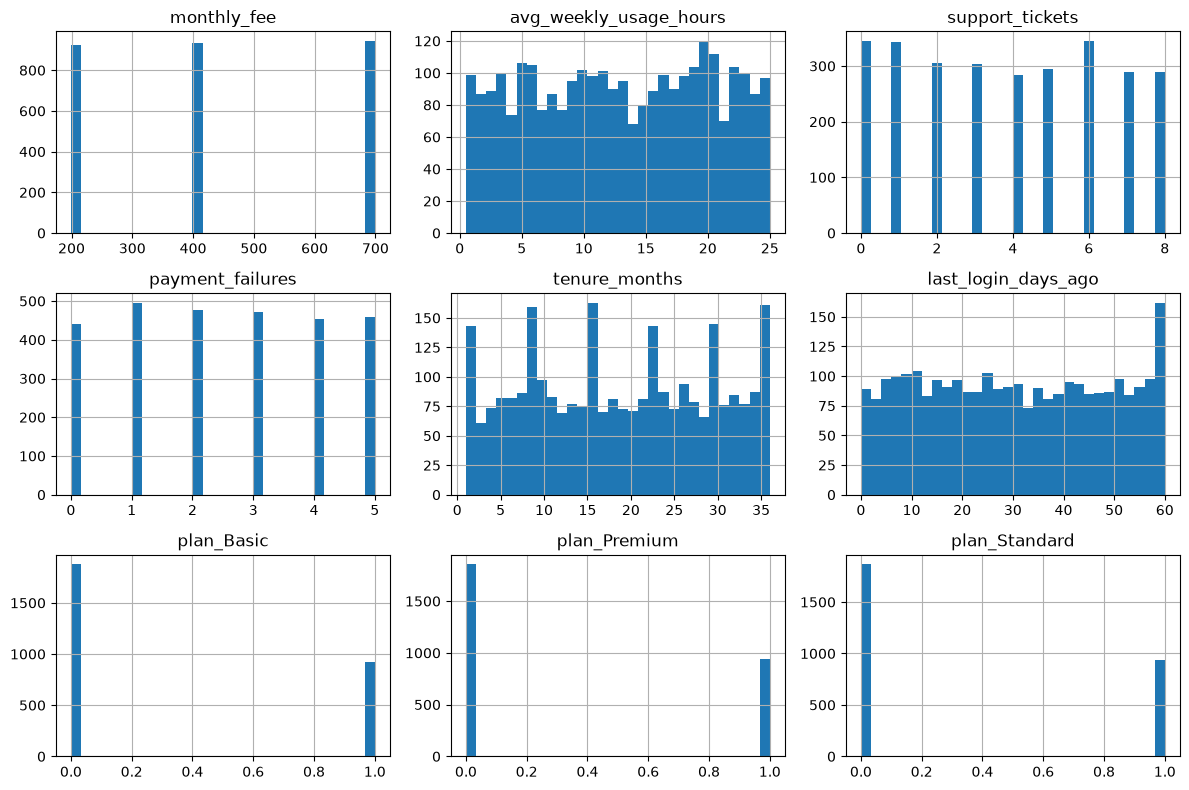

In [12]:
numeric_cols = (
    df.select_dtypes(include='number')
      .drop(columns=['churn_binary', 'user_id'])
      .columns
)
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

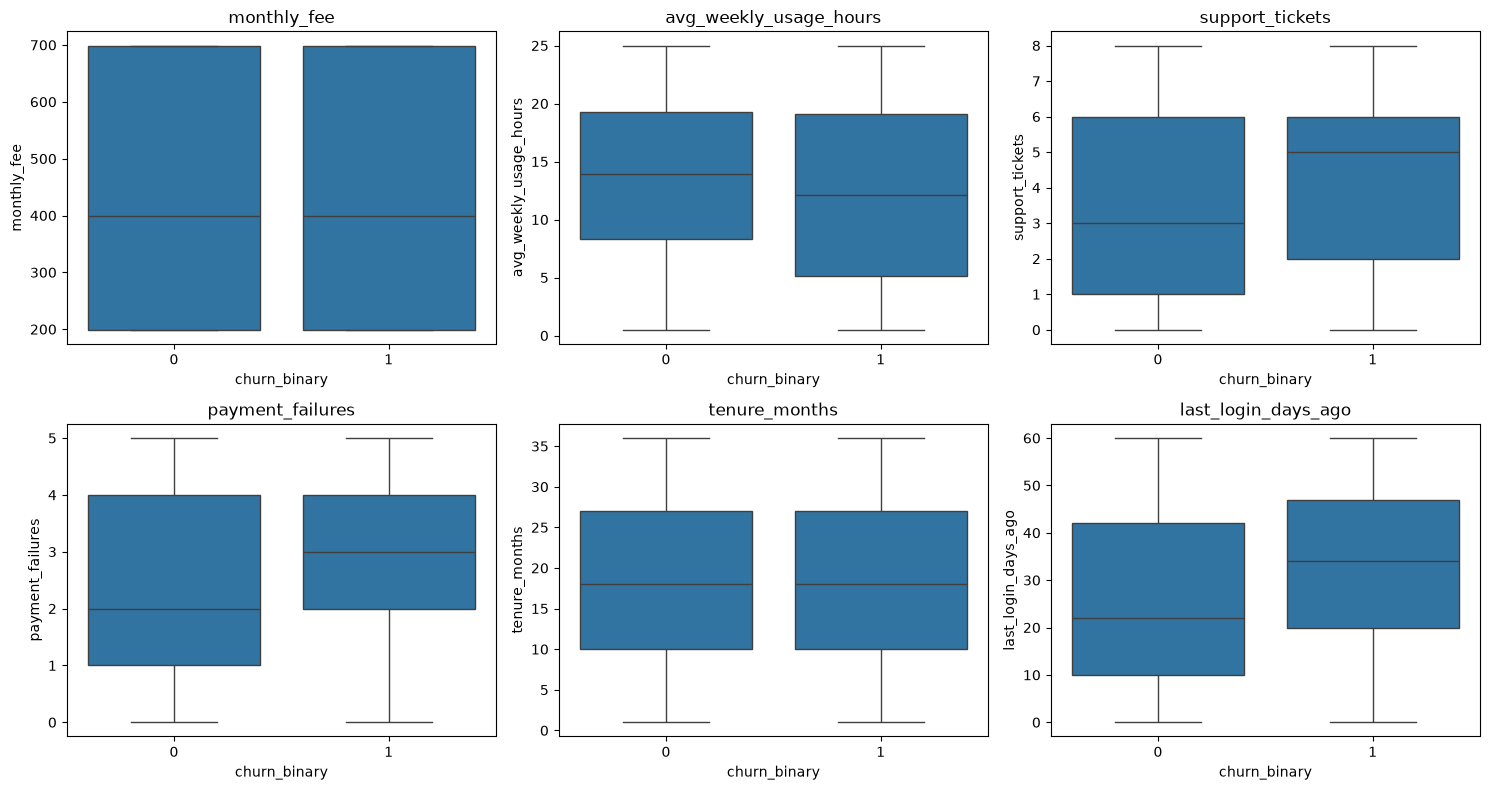

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='churn_binary', y=col, ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

<Axes: >

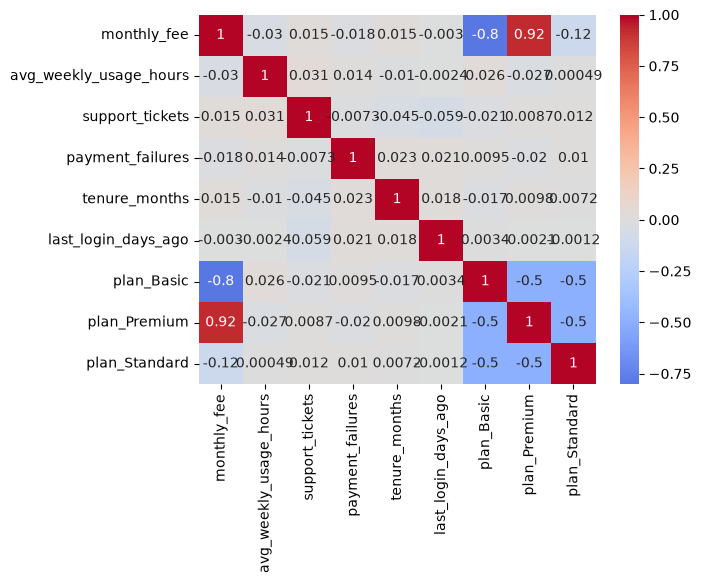

In [14]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

Strongest turn signals: payment_failure (+0.21), last_login_days_ago (+0.19), support_tickets (+0.15)
ave_weekly_usage_hours (-0.10) show that more engaged users are less likely to churn
plan_type, monthly_fee, and tenure_months do not affect churn prediciton that much
plan_type and monthly_fee are the same features. No need to encode plan_type.

In [15]:
churn_by_month = (
    df.groupby(df['signup_date'].dt.to_period('M'))['churn_binary']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'churn_rate', 'count': 'signups'})
)
churn_by_month.index = churn_by_month.index.astype(str)
churn_by_month

,churn_rate,signups
signup_date,,
2023-01,0.613636,88
2023-02,0.625000,112
2023-03,0.515152,99
2023-04,0.525424,118
2023-05,0.528000,125
2023-06,0.528926,121
2023-07,0.516129,124
2023-08,0.605505,109
2023-09,0.613208,106


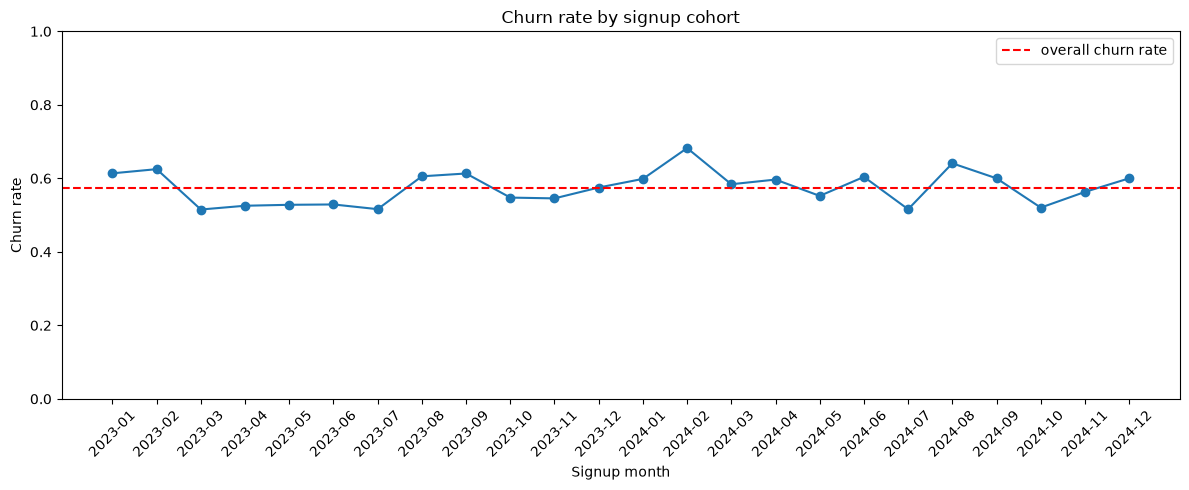

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(churn_by_month.index, churn_by_month['churn_rate'], marker='o')
ax.axhline(df['churn_binary'].mean(), color='red', linestyle='--', label='overall churn rate')
ax.set_xlabel('Signup month')
ax.set_ylabel('Churn rate')
ax.set_title('Churn rate by signup cohort')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Churn rate has some spikes during certain months. Overall, all months have the churn rate around 57%. Could be sample noise instead of meaningful features.